In [1]:
import seaborn as sns
import numpy as np
import scipy.sparse as sp
import scipy
import h5py
import cupy as cp
import matplotlib.pyplot as plt
import cupyx
import cupyx.scipy.sparse.linalg as clinalg
from suppy.feasibility import ExtrapolatedLandweberHyperplane, AdaptiveStepLandweberHyperplane, KaczmarzMethod
from suppy.projections import SequentialProjection, BoxProjection
from suppy.perturbations import PowerSeriesGradientPerturbation
from suppy.feasibility._hyperplanes._conjugated_gradients import ConjugatedGradients

from suppy.superiorization import Superiorization

## Load data

In [ ]:
A = sp.csr_array(sp.load_npz('CT.npz'))  

In [3]:
slice = 14
b = h5py.File("observation_test/observation_test_000.hdf5", "r")['data'][slice].flatten()
true_sol = h5py.File("ground_truth_test/ground_truth_test_000.hdf5", "r")['data'][slice].flatten()

In [4]:
A_red = A[A.sum(axis = 1)>0,:]
b_red = b[A.sum(axis = 1)>0]

## Define perturbation functions

In [5]:
class TV_Objective:
    def __init__(self,N):
        self.N = N
        self.x = None
        self.TV = None
        self.TV_grad = None
        self.TV_ij = None
    
    def calc_quantities(self, x):
        xp  = np if isinstance(x, np.ndarray) else cp
        self.x = x.copy()
        diff_x = xp.diff(x, axis=1)
        diff_y = xp.diff(x, axis=0)
        M1 = xp.pad(diff_x, ((0, 0), (0, 1)), mode='constant')
        M2 = xp.pad(diff_y, ((0, 1), (0, 0)), mode='constant')

        TV_ij = xp.sqrt(M1**2 + M2**2)
        self.TV_ij = TV_ij.copy()
        self.TV= xp.sum(TV_ij)

        TV_ij[TV_ij == 0] = xp.inf  # No contribution to subgradient
        self.TV_grad = xp.zeros_like(TV_ij)
        self.TV_grad -= (M1+M2)/ TV_ij # contribution from TV of own voxel
        self.TV_grad[1:,:] += diff_y / TV_ij[:-1,:] # contribution from TV of neighbour voxel above
        self.TV_grad[:,1:] += diff_x / TV_ij[:,:-1] # contribution from TV of neighbour voxel on top

    def objective(self, x):
        xp  = np if isinstance(x, np.ndarray) else cp
        x = x.reshape((self.N,self.N))        
        if self.x is None or not xp.array_equal(self.x, x):
            self.calc_quantities(x)
        return self.TV

    def gradient(self, x):
        xp  = np if isinstance(x, np.ndarray) else cp
        x = x.reshape((self.N,self.N))
        if self.x is None or not xp.array_equal(self.x, x):
            self.calc_quantities(x)
        return self.TV_grad.reshape((self.N**2))

In [6]:
class VarianceStoppingCriterion:

    def __init__(self,level):
        self._last_x = None
        self.w_history = []
        self.variance_history = []
        self.level = level

    def initial_call(self, x, algorithm):
        self._last_x = x.copy()
        return False

    def evaluate(self, x, algorithm):
        #this should only happen in the first iteration
        self.w_history.append((cp.linalg.norm(x - self._last_x)/cp.linalg.norm(x)).get())
        self._last_x = x.copy()
        self.variance_history.append(np.var(self.w_history))
        #already called once
        if len(self.variance_history) > 1 and self.variance_history[-1] < self.level:
            return True
        return False
        #evaluation 
    

## Run with feasibility seeking only

In [7]:
cpu_norm = sp.linalg.norm(A_red, axis=1)
A_red_cp = cupyx.scipy.sparse.csr_matrix(A_red)
b_red_cp = cp.array(b_red)
x0 = cp.zeros(A_red.shape[1])

### Adaptive Landweber with stopping criterion

In [8]:
import time


obj_cp = TV_Objective(N=362)
orth_proj = BoxProjection(0,1)
stop_crit_feas = VarianceStoppingCriterion(0.01)

pert_al = PowerSeriesGradientPerturbation(obj_cp.objective,obj_cp.gradient,step_size = 0.99,n_restart= 50, n_red = 4)



t_1 = time.time()
alg_feasibility_al  = AdaptiveStepLandweberHyperplane(A_red_cp, cp.asarray(b_red_cp))

sol_feasibility_al = alg_feasibility_al.solve(cp.zeros(A_red_cp.shape[1]),
                                        max_iter = 300,
                                        proximity_measures = [("p_norm",2),"max_norm"],
                                        storage = True,
                                        prox_tol = 1e-8,
                                        del_prox_tol = 1e-10)
print("EMR Time without stopping criterion: ", time.time() - t_1)


t_1 = time.time()
alg_feasibility_al_early  = AdaptiveStepLandweberHyperplane(A_red_cp, cp.asarray(b_red_cp))
sol_feasibility_al_early = alg_feasibility_al_early.solve(cp.zeros(A_red_cp.shape[1]),
                                        max_iter = 300,
                                        proximity_measures = [("p_norm",2),"max_norm"],
                                        storage = True,
                                        prox_tol = 1e-8,
                                        del_prox_tol = 1e-10,
                                        alternative_stopping_criterion=stop_crit_feas.evaluate,
                                        alternative_stopping_criterion_initial_call= stop_crit_feas.initial_call)
print("EMR Time with stopping criterion: ", time.time() - t_1)
print(len(alg_feasibility_al_early.all_x))

EMR Time without stopping criterion:  10.049521207809448
EMR Time with stopping criterion:  3.659573793411255
110


In [9]:
stop_crit_sup = VarianceStoppingCriterion(0.01)

pert_al = PowerSeriesGradientPerturbation(obj_cp.objective,obj_cp.gradient,step_size = 0.99,n_restart= 50, n_red = 4, step_size_modifier= 5)

t_start = time.time()

alg_superiorization_al = Superiorization(alg_feasibility_al,pert_al)
sol_superiorization_al = alg_superiorization_al.solve(cp.zeros(A_red_cp.shape[1]),
                                                max_iter = 300,
                                                proximity_measures = [("p_norm",2),"max_norm"],
                                                storage = True)

print("Superiorized EMR Time: ", time.time() - t_start)

t_start = time.time()
alg_superiorization_al_early = Superiorization(alg_feasibility_al_early,pert_al)
sol_superiorization_al_early = alg_superiorization_al_early.solve(cp.zeros(A_red_cp.shape[1]),
                                                max_iter = 300,
                                                proximity_measures = [("p_norm",2),"max_norm"],
                                                storage = True,
                                                alternative_stopping_criterion=stop_crit_sup.evaluate,
                                                alternative_stopping_criterion_initial_call= stop_crit_sup.initial_call)
print("Superiorized EMR Time with stopping criterion: ", time.time() - t_start)
print(len(alg_superiorization_al_early.all_x_basic))

Superiorized EMR Time:  17.270745754241943
Superiorized EMR Time with stopping criterion:  6.746098756790161
110


## On the CPU

In [10]:


obj = TV_Objective(N=362)
orth_proj = BoxProjection(0,1)
stop_crit_feas = VarianceStoppingCriterion(0.01)

pert_al_cpu =  PowerSeriesGradientPerturbation(obj.objective,obj.gradient,step_size = 0.99,n_restart= 50, n_red = 4)



t_1 = time.time()
alg_feasibility_al_cpu = AdaptiveStepLandweberHyperplane(A_red, b_red)

sol_feasibility_al_cpu = alg_feasibility_al_cpu.solve(np.zeros(A_red_cp.shape[1]),
                                        max_iter = 300,
                                        proximity_measures = [("p_norm",2),"max_norm"],
                                        storage = True,
                                        prox_tol = 1e-8,
                                        del_prox_tol = 1e-10)
print("EMR Time without stopping criterion: ", time.time() - t_1)


t_1 = time.time()
alg_feasibility_al_early_cpu  = AdaptiveStepLandweberHyperplane(A_red, b_red)
sol_feasibility_al_early_cpu = alg_feasibility_al_early_cpu.solve(np.zeros(A_red.shape[1]),
                                        max_iter = 300,
                                        proximity_measures = [("p_norm",2),"max_norm"],
                                        storage = True,
                                        prox_tol = 1e-8,
                                        del_prox_tol = 1e-10,
                                        alternative_stopping_criterion=stop_crit_feas.evaluate,
                                        alternative_stopping_criterion_initial_call= stop_crit_feas.initial_call)
print("EMR Time with stopping criterion: ", time.time() - t_1)
print(len(alg_feasibility_al_early_cpu.all_x))

EMR Time without stopping criterion:  235.28748893737793
EMR Time with stopping criterion:  85.71824240684509
110


In [11]:
stop_crit_sup_cpu = VarianceStoppingCriterion(0.01)

pert_al_cpu = PowerSeriesGradientPerturbation(obj.objective,obj.gradient,step_size = 0.99,n_restart= 50, n_red = 4, step_size_modifier= 5)

t_start = time.time()

alg_superiorization_al_cpu = Superiorization(alg_feasibility_al_cpu,pert_al_cpu)
sol_superiorization_al_cpu = alg_superiorization_al_cpu.solve(np.zeros(A_red_cp.shape[1]),
                                                max_iter = 300,
                                                proximity_measures = [("p_norm",2),"max_norm"],
                                                storage = True)

print("Superiorized EMR Time: ", time.time() - t_start)

t_start = time.time()
alg_superiorization_al_early_cpu = Superiorization(alg_feasibility_al_early_cpu,pert_al_cpu)
sol_superiorization_al_early_cpu = alg_superiorization_al_early_cpu.solve(np.zeros(A_red_cp.shape[1]),
                                                max_iter = 300,
                                                proximity_measures = [("p_norm",2),"max_norm"],
                                                storage = True,
                                                alternative_stopping_criterion=stop_crit_sup_cpu.evaluate,
                                                alternative_stopping_criterion_initial_call= stop_crit_sup_cpu.initial_call)
print("Superiorized EMR Time with stopping criterion: ", time.time() - t_start)
print(len(alg_superiorization_al_early_cpu.all_x_basic))

Superiorized EMR Time:  347.7604019641876
Superiorized EMR Time with stopping criterion:  135.2721450328827
110


In [12]:
rel_errors_feasibility_al = np.array([np.linalg.norm(x_el - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_el in alg_feasibility_al.all_x])
rel_errors_superiorization_al = np.array([np.linalg.norm(x_el - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_el in alg_superiorization_al.all_x_basic])

rel_errors_feasibility_al_early = np.array([np.linalg.norm(x_el - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_el in alg_feasibility_al_early.all_x])
rel_errors_superiorization_al_early = np.array([np.linalg.norm(x_el - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_el in alg_superiorization_al_early.all_x_basic])

In [13]:
rel_errors_feasibility_al_cpu = np.array([np.linalg.norm(x_el - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_el in alg_feasibility_al_cpu.all_x])
rel_errors_superiorization_al_cpu = np.array([np.linalg.norm(x_el - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_el in alg_superiorization_al_cpu.all_x_basic])
rel_errors_feasibility_al_early_cpu = np.array([np.linalg.norm(x_el - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_el in alg_feasibility_al_early_cpu.all_x])
rel_errors_superiorization_al_early_cpu = np.array([np.linalg.norm(x_el - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_el in alg_superiorization_al_early_cpu.all_x_basic])

In [14]:
print(rel_errors_feasibility_al.argmin(), rel_errors_superiorization_al.argmin())
print(rel_errors_feasibility_al.min(), rel_errors_superiorization_al.min())

60 250
0.09252957010581009 0.0656057101167547


In [15]:
print(rel_errors_feasibility_al_early.argmin(), rel_errors_superiorization_al_early.argmin())
print(rel_errors_feasibility_al_early.min(), rel_errors_superiorization_al_early.min())

60 100
0.09252957010581009 0.0748222639726519


In [16]:
print(rel_errors_feasibility_al_cpu.argmin(), rel_errors_superiorization_al_cpu.argmin())
print(rel_errors_feasibility_al_cpu.min(), rel_errors_superiorization_al_cpu.min())
print(rel_errors_feasibility_al_early_cpu.argmin(), rel_errors_superiorization_al_early_cpu.argmin())
print(rel_errors_feasibility_al_early_cpu.min(), rel_errors_superiorization_al_early_cpu.min())

60 250
0.09252957010581009 0.06561096400435112
60 100
0.09252957010581009 0.07483701744057589


### Extrapolated Landweber with stopping criterion

In [17]:
stop_crit_feas = VarianceStoppingCriterion(0.01)

alg_feasibility_el = ExtrapolatedLandweberHyperplane(A_red_cp, cp.asarray(b_red_cp))

t_2 = time.time()
sol_feasibility_el = alg_feasibility_el.solve(cp.zeros(A_red_cp.shape[1]),
                                        max_iter = 300,
                                        proximity_measures = [("p_norm",2),"max_norm"],
                                        storage = True,
                                        prox_tol = 1e-8,
                                        del_prox_tol = 1e-10)
print("Extrapolated Landweber Time: ", time.time() - t_2)


t_2  = time.time()

alg_feasibility_el_early = ExtrapolatedLandweberHyperplane(A_red_cp, cp.asarray(b_red_cp))
sol_feasibility_el_early = alg_feasibility_el_early.solve(cp.zeros(A_red_cp.shape[1]),
                                        max_iter = 300,
                                        proximity_measures = [("p_norm",2),"max_norm"],
                                        storage = True,
                                        prox_tol = 1e-8,
                                        del_prox_tol = 1e-10,
                                        alternative_stopping_criterion=stop_crit_feas.evaluate,
                                        alternative_stopping_criterion_initial_call= stop_crit_feas.initial_call)

print("Extrapolated Landweber Time with stopping criterion: ", time.time() - t_2)

Extrapolated Landweber Time:  7.189105987548828
Extrapolated Landweber Time with stopping criterion:  7.593574285507202


In [18]:
print(len(alg_feasibility_el_early.all_x))

301


In [19]:
stop_crit_sup = VarianceStoppingCriterion(0.01)

pert_el = PowerSeriesGradientPerturbation(obj_cp.objective,obj_cp.gradient,step_size = 0.99,n_restart= 50, n_red = 4, step_size_modifier= 5)

t_start = time.time()

alg_superiorization_el = Superiorization(alg_feasibility_el,pert_el)
sol_superiorization_el = alg_superiorization_el.solve(cp.zeros(A_red_cp.shape[1]),
                                                max_iter = 300,
                                                proximity_measures = [("p_norm",2),"max_norm"],
                                                storage = True)

print("Superiorized Extrapolated Landweber Time: ", time.time() - t_start)

t_start = time.time()
alg_superiorization_el_early = Superiorization(alg_feasibility_el_early,pert_el)
sol_superiorization_el_early = alg_superiorization_el_early.solve(cp.zeros(A_red_cp.shape[1]),
                                                max_iter = 300,
                                                proximity_measures = [("p_norm",2),"max_norm"],
                                                storage = True,
                                                alternative_stopping_criterion=stop_crit_sup.evaluate,
                                                alternative_stopping_criterion_initial_call= stop_crit_sup.initial_call)
print("Superiorized Extrapolated Landweber Time with stopping criterion: ", time.time() - t_start)
print(len(alg_superiorization_el_early.all_x_basic))

Superiorized Extrapolated Landweber Time:  15.112161636352539
Superiorized Extrapolated Landweber Time with stopping criterion:  15.04960298538208
301


## Run on the CPU

In [20]:
stop_crit_feas_cpu = VarianceStoppingCriterion(0.01)

alg_feasibility_el_cpu = ExtrapolatedLandweberHyperplane(A_red, b_red)

t_2 = time.time()
sol_feasibility_el_cpu = alg_feasibility_el_cpu.solve(np.zeros(A_red.shape[1]),
                                        max_iter = 300,
                                        proximity_measures = [("p_norm",2),"max_norm"],
                                        storage = True,
                                        prox_tol = 1e-8,
                                        del_prox_tol = 1e-10)
print("Extrapolated Landweber Time: ", time.time() - t_2)


t_2  = time.time()

alg_feasibility_el_early_cpu = ExtrapolatedLandweberHyperplane(A_red, b_red)
sol_feasibility_el_early_cpu = alg_feasibility_el_early_cpu.solve(np.zeros(A_red.shape[1]),
                                        max_iter = 300,
                                        proximity_measures = [("p_norm",2),"max_norm"],
                                        storage = True,
                                        prox_tol = 1e-8,
                                        del_prox_tol = 1e-10,
                                        alternative_stopping_criterion=stop_crit_feas.evaluate,
                                        alternative_stopping_criterion_initial_call= stop_crit_feas.initial_call)

print("Extrapolated Landweber Time with stopping criterion: ", time.time() - t_2)

Extrapolated Landweber Time:  182.60033798217773
Extrapolated Landweber Time with stopping criterion:  202.37571549415588


In [21]:
stop_crit_sup_cpu = VarianceStoppingCriterion(0.01)

pert_el_cpu = PowerSeriesGradientPerturbation(obj.objective,obj.gradient,step_size = 0.99,n_restart= 50, n_red = 4, step_size_modifier= 5)

t_start = time.time()

alg_superiorization_el_cpu = Superiorization(alg_feasibility_el_cpu,pert_el_cpu)
sol_superiorization_el_cpu = alg_superiorization_el_cpu.solve(np.zeros(A_red_cp.shape[1]),
                                                max_iter = 300,
                                                proximity_measures = [("p_norm",2),"max_norm"],
                                                storage = True)

print("Superiorized Extrapolated Landweber Time: ", time.time() - t_start)

t_start = time.time()
alg_superiorization_el_early_cpu = Superiorization(alg_feasibility_el_early_cpu,pert_el_cpu)
sol_superiorization_el_early_cpu = alg_superiorization_el_early_cpu.solve(np.zeros(A_red_cp.shape[1]),
                                                max_iter = 300,
                                                proximity_measures = [("p_norm",2),"max_norm"],
                                                storage = True,
                                                alternative_stopping_criterion=stop_crit_sup_cpu.evaluate,
                                                alternative_stopping_criterion_initial_call= stop_crit_sup_cpu.initial_call)
print("Superiorized Extrapolated Landweber Time with stopping criterion: ", time.time() - t_start)
print(len(alg_superiorization_el_early_cpu.all_x_basic))

Superiorized Extrapolated Landweber Time:  277.5377564430237
Superiorized Extrapolated Landweber Time with stopping criterion:  244.10567426681519
301


In [22]:
rel_errors_feasibility_el = np.array([np.linalg.norm(x_el - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_el in alg_feasibility_el.all_x])
rel_errors_superiorization_el = np.array([np.linalg.norm(x_el - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_el in alg_superiorization_el.all_x_basic])

rel_errors_feasibility_el_early = np.array([np.linalg.norm(x_el - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_el in alg_feasibility_el_early.all_x])
rel_errors_superiorization_el_early = np.array([np.linalg.norm(x_el - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_el in alg_superiorization_el_early.all_x_basic])

In [23]:
rel_errors_feasibility_el_cpu = np.array([np.linalg.norm(x_el - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_el in alg_feasibility_el_cpu.all_x])
rel_errors_superiorization_el_cpu = np.array([np.linalg.norm(x_el - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_el in alg_superiorization_el_cpu.all_x_basic])

rel_errors_feasibility_el_early_cpu = np.array([np.linalg.norm(x_el - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_el in alg_feasibility_el_early_cpu.all_x])
rel_errors_superiorization_el_early_cpu = np.array([np.linalg.norm(x_el - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_el in alg_superiorization_el_early_cpu.all_x_basic])

In [24]:
print(rel_errors_feasibility_el.argmin(), rel_errors_superiorization_el.argmin())
print(rel_errors_feasibility_el.min(), rel_errors_superiorization_el.min())

49 249
0.32057009388197766 0.3158197707120329


In [25]:
print(rel_errors_feasibility_el_early.argmin(), rel_errors_superiorization_el_early.argmin())
print(rel_errors_feasibility_el_early.min(), rel_errors_superiorization_el_early.min())

49 249
0.32057009388197777 0.315819637235774


In [26]:
print(rel_errors_feasibility_el_cpu.argmin(), rel_errors_superiorization_el_cpu.argmin())
print(rel_errors_feasibility_el_cpu.min(), rel_errors_superiorization_el_cpu.min())
print(rel_errors_feasibility_el_early_cpu.argmin(), rel_errors_superiorization_el_early_cpu.argmin())
print(rel_errors_feasibility_el_early_cpu.min(), rel_errors_superiorization_el_early_cpu.min())

49 249
0.32057009388197966 0.31582533411390085
49 249
0.32057009388197966 0.31582533411390085


### Conjugated Gradients with stopping criterion

In [27]:
stop_crit_feas = VarianceStoppingCriterion(0.01)

alg_feasibility_cg = ConjugatedGradients(A_red_cp, cp.asarray(b_red_cp))
t_4 = time.time()
sol_feasibility_cg = alg_feasibility_cg.solve(cp.zeros(A_red_cp.shape[1]),
                                        max_iter = 300,
                                        proximity_measures = [("p_norm",2),"max_norm"],
                                        storage = True,
                                        prox_tol = 1e-10,
                                        del_prox_tol = 1e-12)
print("Conjugated Gradients Time: ", time.time() - t_4)

t_4  = time.time()
alg_feasibility_cg_early = ConjugatedGradients(A_red_cp, cp.asarray(b_red_cp))
sol_feasibility_cg_early = alg_feasibility_cg_early.solve(cp.zeros(A_red_cp.shape[1]),
                                        max_iter = 300,
                                        proximity_measures = [("p_norm",2),"max_norm"],
                                        storage = True,
                                        prox_tol = 1e-10,
                                        del_prox_tol = 1e-12,
                                        alternative_stopping_criterion=stop_crit_feas.evaluate,
                                        alternative_stopping_criterion_initial_call= stop_crit_feas.initial_call)
print("Conjugated Gradients Time with stopping criterion: ", time.time() - t_4)

Conjugated Gradients Time:  9.388884782791138
Conjugated Gradients Time with stopping criterion:  3.6843981742858887


In [28]:
stop_crit_sup = VarianceStoppingCriterion(0.01)



pert_cg = PowerSeriesGradientPerturbation(obj_cp.objective,obj_cp.gradient,step_size = 0.99,n_restart= 50, n_red = 4, step_size_modifier= 5)
_alg_feasibility_cg = ConjugatedGradients(A_red_cp, cp.asarray(b_red_cp))
alg_superiorization_cg = Superiorization(_alg_feasibility_cg,pert_cg)
t_start = time.time()
alg_superiorization_cg.solve(cp.zeros(A_red_cp.shape[1]),
                                                max_iter = 300,proximity_measures = [("p_norm",2),"max_norm"],
                                                storage = True)
print("Superiorized Conjugated Gradients Time: ", time.time() - t_start)


Superiorized Conjugated Gradients Time:  15.482428550720215


In [29]:
pert_cg = PowerSeriesGradientPerturbation(obj_cp.objective,obj_cp.gradient,step_size = 0.99,n_restart= 50, n_red = 4, step_size_modifier= 5)


t_start = time.time()
_alg_feasibility_cg_early = ConjugatedGradients(A_red_cp, cp.asarray(b_red_cp))
alg_superiorization_cg_early = Superiorization(_alg_feasibility_cg_early,pert_cg)
sol_superiorization_cg_early = alg_superiorization_cg_early.solve(cp.zeros(A_red_cp.shape[1]),
                                                max_iter = 300,
                                                proximity_measures = [("p_norm",2),"max_norm"],
                                                storage = True,
                                                alternative_stopping_criterion=stop_crit_sup.evaluate,
                                                alternative_stopping_criterion_initial_call= stop_crit_sup.initial_call)
print("Superiorized Conjugate Gradient Time with stopping criterion: ", time.time() - t_start)
print(len(alg_superiorization_cg_early.all_x_basic))

Superiorized Conjugate Gradient Time with stopping criterion:  6.309903383255005
116


## Run on the CPU

In [30]:
stop_crit_feas_cpu = VarianceStoppingCriterion(0.01)

alg_feasibility_cg_cpu = ConjugatedGradients(A_red, b_red)
t_4 = time.time()
sol_feasibility_cg_cpu = alg_feasibility_cg_cpu.solve(np.zeros(A_red.shape[1]),
                                        max_iter = 300,
                                        proximity_measures = [("p_norm",2),"max_norm"],
                                        storage = True,
                                        prox_tol = 1e-10,
                                        del_prox_tol = 1e-12)
print("Conjugated Gradients Time: ", time.time() - t_4)

t_4  = time.time()
alg_feasibility_cg_early_cpu = ConjugatedGradients(A_red, b_red)
sol_feasibility_cg_early_cpu = alg_feasibility_cg_early_cpu.solve(np.zeros(A_red.shape[1]),
                                        max_iter = 300,
                                        proximity_measures = [("p_norm",2),"max_norm"],
                                        storage = True,
                                        prox_tol = 1e-10,
                                        del_prox_tol = 1e-12,
                                        alternative_stopping_criterion=stop_crit_feas_cpu.evaluate,
                                        alternative_stopping_criterion_initial_call= stop_crit_feas_cpu.initial_call)
print("Conjugated Gradients Time with stopping criterion: ", time.time() - t_4)

Conjugated Gradients Time:  229.9238202571869
Conjugated Gradients Time with stopping criterion:  83.08329892158508


In [31]:
stop_crit_sup_cpu = VarianceStoppingCriterion(0.01)



pert_cg_cpu = PowerSeriesGradientPerturbation(obj.objective,obj.gradient,step_size = 0.99,n_restart= 50, n_red = 4, step_size_modifier= 5)
_alg_feasibility_cg_cpu = ConjugatedGradients(A_red, b_red)
alg_superiorization_cg_cpu = Superiorization(_alg_feasibility_cg_cpu,pert_cg_cpu)
t_start = time.time()
sol_alg_superiorization_cg_cpu = alg_superiorization_cg_cpu.solve(np.zeros(A_red.shape[1]),
                                                max_iter = 300,proximity_measures = [("p_norm",2),"max_norm"],
                                                storage = True)
print("Superiorized Conjugated Gradients Time: ", time.time() - t_start)


Superiorized Conjugated Gradients Time:  286.800039768219


In [32]:
pert_cg_cpu = PowerSeriesGradientPerturbation(obj.objective,obj.gradient,step_size = 0.99,n_restart= 50, n_red = 4, step_size_modifier= 5)


t_start = time.time()
_alg_feasibility_cg_early_cpu = ConjugatedGradients(A_red, b_red)
alg_superiorization_cg_early_cpu = Superiorization(_alg_feasibility_cg_early_cpu,pert_cg_cpu)
sol_superiorization_cg_early_cpu = alg_superiorization_cg_early_cpu.solve(np.zeros(A_red.shape[1]),
                                                max_iter = 300,
                                                proximity_measures = [("p_norm",2),"max_norm"],
                                                storage = True,
                                                alternative_stopping_criterion=stop_crit_sup.evaluate,
                                                alternative_stopping_criterion_initial_call= stop_crit_sup.initial_call)
print("Superiorized Conjugate Gradient Time with stopping criterion: ", time.time() - t_start)
print(len(alg_superiorization_cg_early_cpu.all_x_basic))

Superiorized Conjugate Gradient Time with stopping criterion:  111.66449904441833
115


In [33]:
rel_errors_feasibility_cg = np.array([np.linalg.norm(x_cg - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_cg in alg_feasibility_cg.all_x])
rel_errors_superiorization_cg = np.array([np.linalg.norm(x_cg - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_cg in alg_superiorization_cg.all_x_basic])

rel_errors_feasibility_cg_early = np.array([np.linalg.norm(x_cg - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_cg in alg_feasibility_cg_early.all_x])
rel_errors_superiorization_cg_early = np.array([np.linalg.norm(x_cg - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_cg in alg_superiorization_cg_early.all_x_basic])

In [34]:
print(rel_errors_feasibility_cg.argmin(), rel_errors_superiorization_cg.argmin())
print(rel_errors_feasibility_cg.min(), rel_errors_superiorization_cg.min())

9 118
0.0900811907922646 0.06790408532866297


In [35]:
print(rel_errors_feasibility_cg_early.argmin(), rel_errors_superiorization_cg_early.argmin())
print(rel_errors_feasibility_cg_early.min(), rel_errors_superiorization_cg_early.min())

9 115
0.09008119079226436 0.06937990652498154


### Kaczmarz Method with stopping criterion

In [36]:
stop_crit_feas = VarianceStoppingCriterion(0.01)

alg_feasibility_seq = KaczmarzMethod(A_red, b_red)
t_3 = time.time()
sol_feasibility_seq = alg_feasibility_seq.solve(np.zeros(A_red.shape[1]),
                                        max_iter = 300,
                                        proximity_measures = [("p_norm",2),"max_norm"],
                                        storage = True,
                                        prox_tol = 1e-8,
                                        del_prox_tol = 1e-10)
print("Kaczmarz Method Time: ", time.time() - t_3)



Kaczmarz Method Time:  1447.44846367836


In [37]:
t_3 = time.time()
alg_feasibility_seq_early = KaczmarzMethod(A_red, b_red)
sol_feasibility_seq_early = alg_feasibility_seq_early.solve(np.zeros(A_red.shape[1]),
                                        max_iter = 300,
                                        proximity_measures = [("p_norm",2),"max_norm"],
                                        storage = True,
                                        prox_tol = 1e-8,
                                        del_prox_tol = 1e-10,
                                        alternative_stopping_criterion=stop_crit_feas.evaluate,
                                        alternative_stopping_criterion_initial_call= stop_crit_feas.initial_call)
print("Kaczmarz Method Time with stopping criterion: ", time.time() - t_3)


Kaczmarz Method Time with stopping criterion:  697.6446399688721


## Visualize results

In [38]:
print(len(alg_feasibility_seq_early.all_x))

147


In [39]:
stop_crit_sup = VarianceStoppingCriterion(0.01)

#pert_seq = PowerSeriesGradientPerturbation(obj_cp.objective,obj_cp.gradient,step_size = 0.99,n_restart= 50, n_red = 4, step_size_modifier= 5)

obj_np = TV_Objective(N=362)
pert_seq = PowerSeriesGradientPerturbation(obj_np.objective,obj_np.gradient,step_size = 0.99,n_restart= 50, n_red = 4, step_size_modifier= 5)

t_start = time.time()

alg_superiorization_seq = Superiorization(alg_feasibility_seq,pert_seq)
sol_superiorization = alg_superiorization_seq.solve(np.zeros(A_red.shape[1]),
                                                max_iter = 300,
                                                proximity_measures = [("p_norm",2),"max_norm"],
                                                storage = True)

print("Superiorized EMR Time: ", time.time() - t_start)

t_start = time.time()
alg_superiorization_seq_early = Superiorization(alg_feasibility_seq_early,pert_seq)
sol_superiorization_seq_early = alg_superiorization_seq_early.solve(np.zeros(A_red.shape[1]),
                                                max_iter = 300,
                                                proximity_measures = [("p_norm",2),"max_norm"],
                                                storage = True,
                                                alternative_stopping_criterion=stop_crit_sup.evaluate,
                                                alternative_stopping_criterion_initial_call= stop_crit_sup.initial_call)

print("Superiorized EMR Time with stopping criterion: ", time.time() - t_start)
print(len(alg_superiorization_seq_early.all_x_basic))

Superiorized EMR Time:  1584.2267763614655
Superiorized EMR Time with stopping criterion:  705.8888566493988
144


In [40]:
rel_errors_feasibility_seq = np.array([np.linalg.norm(x_seq - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_seq in alg_feasibility_seq.all_x])
rel_errors_superiorization_seq = np.array([np.linalg.norm(x_seq - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_seq in alg_superiorization_seq.all_x_basic])

In [41]:
rel_errors_feasibility_seq_early = np.array([np.linalg.norm(x_seq - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_seq in alg_feasibility_seq_early.all_x])
rel_errors_superiorization_seq_early = np.array([np.linalg.norm(x_seq - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_seq in alg_superiorization_seq_early.all_x_basic])

In [42]:
from matplotlib.colors import Normalize

idx_feas_al = rel_errors_feasibility_al.argmin()
img_feas_al = alg_feasibility_al.all_x[idx_feas_al].reshape(362, 362).T

idx_sup_al = rel_errors_superiorization_al.argmin()
img_sup_al = alg_superiorization_al.all_x_basic[idx_sup_al].reshape(362, 362).T

idx_stop_feas_early = len(alg_feasibility_al_early.all_x) - 1
idx_stop_sup_early = len(alg_superiorization_al_early.all_x_basic) - 1





## Slice with different algorithms

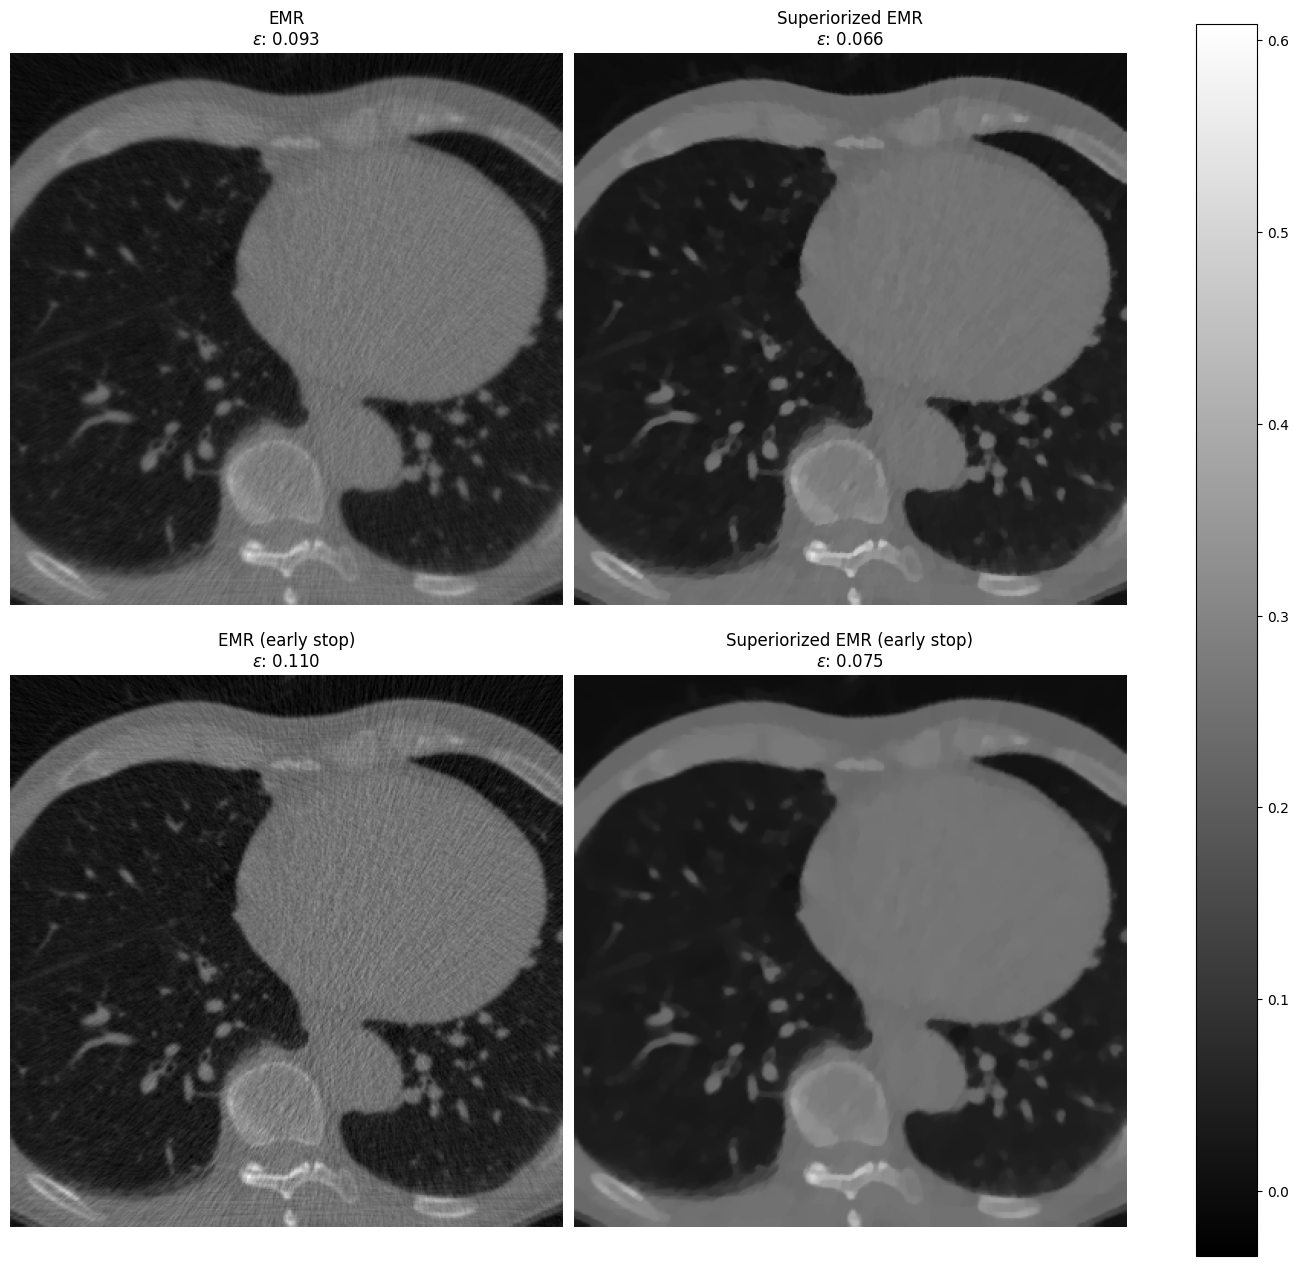

In [43]:
vmin = min(img_feas_al.min(), true_sol.min())
vmax = max(img_feas_al.max(), true_sol.max())
norm = Normalize(vmin=vmin, vmax=vmax)
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(18,16))

p1 = ax[0,0].imshow(img_feas_al, cmap='gray', norm=norm)
p2 = ax[0,1].imshow(img_sup_al, cmap='gray', norm=norm)
p3 = ax[1,0].imshow(sol_feasibility_al_early.get().reshape((362,362)).T, cmap='gray', norm=norm)
p4 = ax[1,1].imshow(alg_superiorization_al_early.all_x[-1].reshape((362,362)).T, cmap='gray', norm=norm)

ax[0,0].set_title(f'EMR\n$\epsilon$: {rel_errors_feasibility_al[idx_feas_al]:.3f}')
ax[0,1].set_title(f'Superiorized EMR\n$\epsilon$: {rel_errors_superiorization_al[idx_sup_al]:.3f}')
ax[1,0].set_title(f'EMR (early stop)\n$\epsilon$: {rel_errors_feasibility_al[idx_stop_feas_early]:.3f}')
ax[1,1].set_title(f'Superiorized EMR (early stop)\n$\epsilon$: {rel_errors_superiorization_al[idx_stop_sup_early]:.3f}')

for a in ax.ravel():
    a.axis('off')

# reduce space between subplots
fig.subplots_adjust(wspace=0.02, hspace=0.02)

fig.colorbar(p1, ax=ax.ravel().tolist())

plt.savefig('CT_stop_criterion_comparison.png', dpi=300)


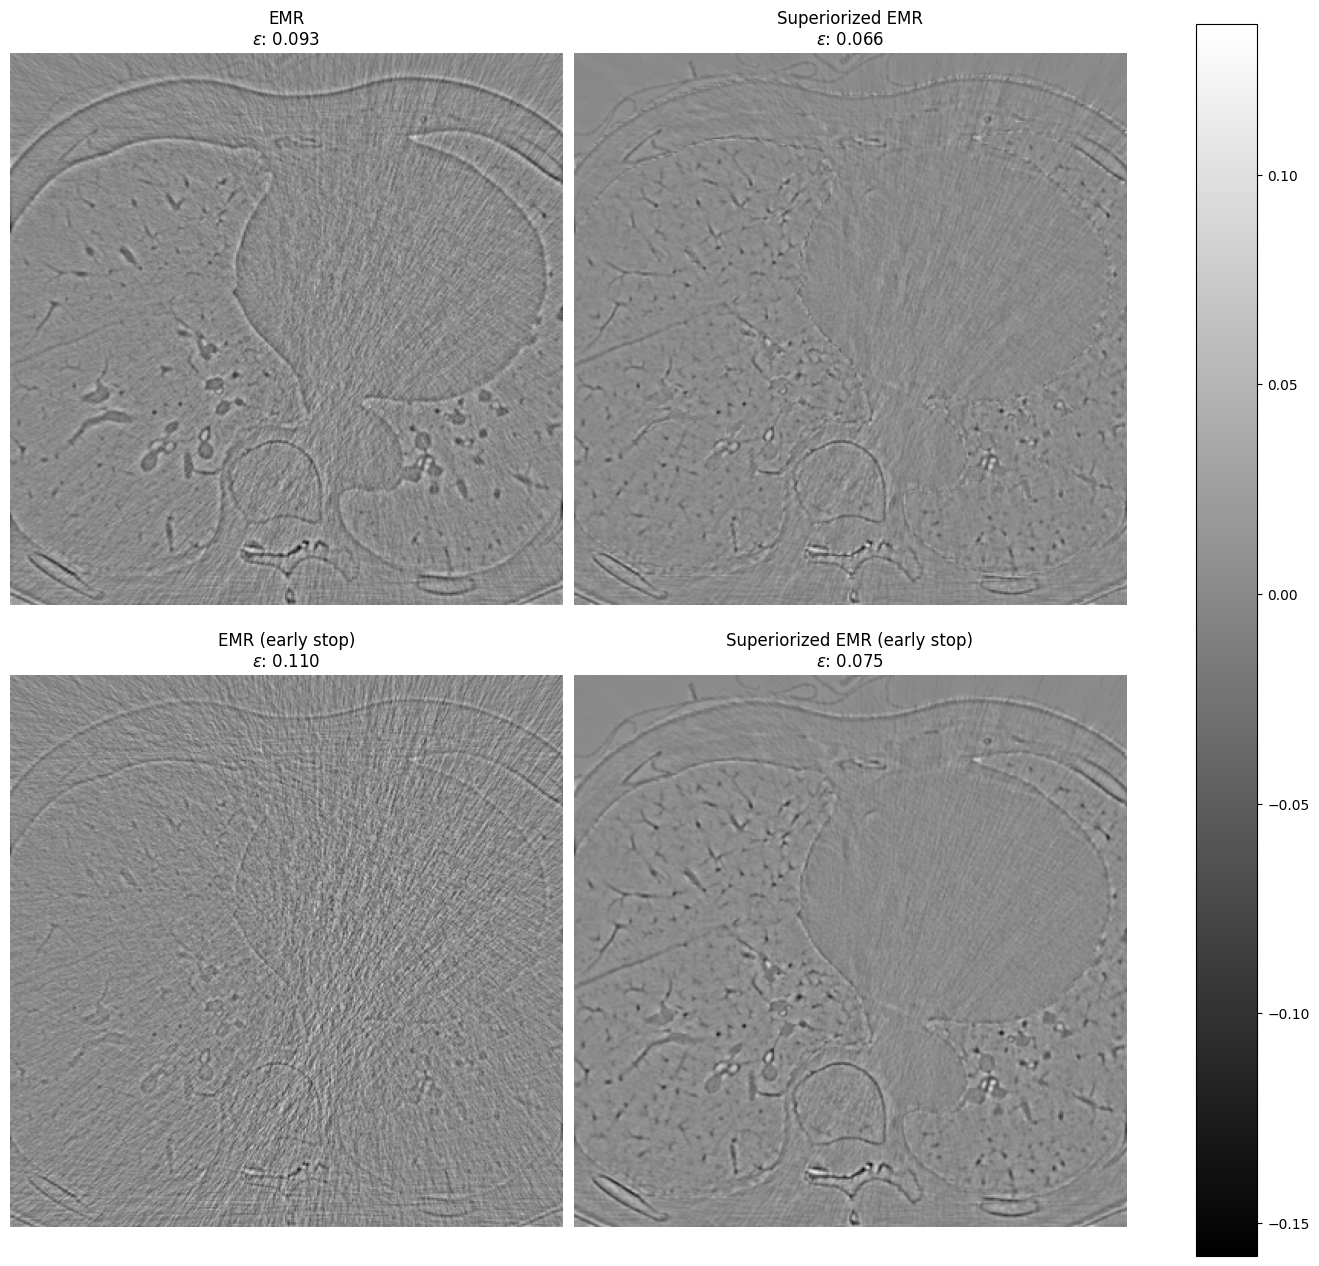

In [44]:
img_feas_al_diff = img_feas_al - true_sol.reshape((362,362)).T
img_sup_al_diff = img_sup_al - true_sol.reshape((362,362)).T

img_feas_al_early_diff = sol_feasibility_al_early.get().reshape((362,362)).T - true_sol.reshape((362,362)).T
img_sup_al_early_diff = sol_superiorization_al_early.get().reshape((362,362)).T - true_sol.reshape((362,362)).T

vmin = min(img_feas_al_diff.min(), img_sup_al_diff.min(), img_feas_al_early_diff.min(), img_sup_al_early_diff.min())
vmax = max(img_feas_al_diff.max(), img_sup_al_diff.max(), img_feas_al_early_diff.max(), img_sup_al_early_diff.max())
norm = Normalize(vmin=vmin, vmax=vmax)
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(18,16))

p1 = ax[0,0].imshow(img_feas_al_diff, cmap='gray', norm=norm)
p2 = ax[0,1].imshow(img_sup_al_diff, cmap='gray', norm=norm)
p3 = ax[1,0].imshow(img_feas_al_early_diff, cmap='gray', norm=norm)
p4 = ax[1,1].imshow(img_sup_al_early_diff, cmap='gray', norm=norm)

ax[0,0].set_title(f'EMR\n$\epsilon$: {rel_errors_feasibility_al[idx_feas_al]:.3f}')
ax[0,1].set_title(f'Superiorized EMR\n$\epsilon$: {rel_errors_superiorization_al[idx_sup_al]:.3f}')
ax[1,0].set_title(f'EMR (early stop)\n$\epsilon$: {rel_errors_feasibility_al[idx_stop_feas_early]:.3f}')
ax[1,1].set_title(f'Superiorized EMR (early stop)\n$\epsilon$: {rel_errors_superiorization_al[idx_stop_sup_early]:.3f}')

for a in ax.ravel():
    a.axis('off')

# reduce space between subplots
fig.subplots_adjust(wspace=0.02, hspace=0.02)

fig.colorbar(p1, ax=ax.ravel().tolist())

plt.savefig('CT_stop_criterion_comparison_diff.png', dpi=300)


### Evolution of relative error for differen strategies

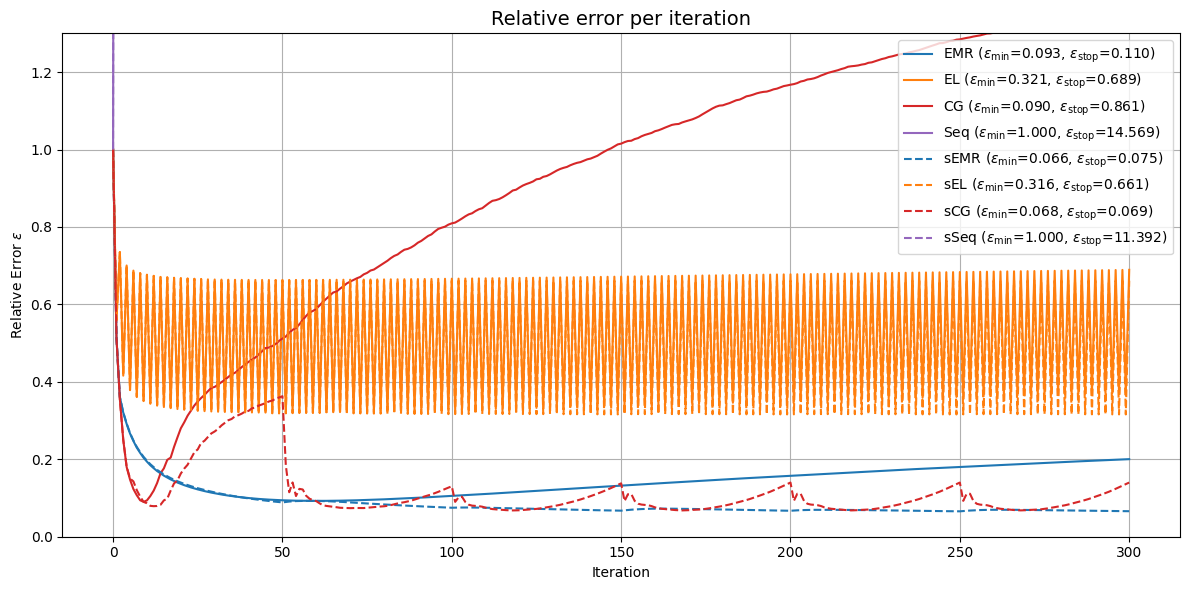

In [45]:
fig, ax = plt.subplots(figsize=(12, 6))

min_al = rel_errors_feasibility_al.min()
min_el = rel_errors_feasibility_el.min()
min_cg = rel_errors_feasibility_cg.min()
min_seq = rel_errors_feasibility_seq.min()

stop_al = rel_errors_feasibility_al_early[-1]
stop_el = rel_errors_feasibility_el_early[-1]
stop_cg = rel_errors_feasibility_cg_early[-1]
stop_seq = rel_errors_feasibility_seq_early[-1]

min_sal = rel_errors_superiorization_al.min()
min_sel = rel_errors_superiorization_el.min()
min_scg = rel_errors_superiorization_cg.min()
min_sseq = rel_errors_superiorization_seq.min()

stop_sal = rel_errors_superiorization_al_early[-1]
stop_sel = rel_errors_superiorization_el_early[-1]
stop_scg = rel_errors_superiorization_cg_early[-1]
stop_sseq = rel_errors_superiorization_seq_early[-1]

ax.plot(rel_errors_feasibility_al, label=f'EMR ($\\epsilon_{{\\min}}$={min_al:.3f}, $\\epsilon_{{\\text{{stop}}}}$={stop_al:.3f})', color='C0')
ax.plot(rel_errors_feasibility_el, label=f'EL ($\\epsilon_{{\\min}}$={min_el:.3f}, $\\epsilon_{{\\text{{stop}}}}$={stop_el:.3f})', color='C1')
ax.plot(rel_errors_feasibility_cg, label=f'CG ($\\epsilon_{{\\min}}$={min_cg:.3f}, $\\epsilon_{{\\text{{stop}}}}$={stop_cg:.3f})', color='C3')
ax.plot(rel_errors_feasibility_seq, label=f'Seq ($\\epsilon_{{\\min}}$={min_seq:.3f}, $\\epsilon_{{\\text{{stop}}}}$={stop_seq:.3f})', color='C4')

ax.plot(rel_errors_superiorization_al, label=f'sEMR ($\\epsilon_{{\\min}}$={min_sal:.3f}, $\\epsilon_{{\\text{{stop}}}}$={stop_sal:.3f})', color='C0', linestyle='--')
ax.plot(rel_errors_superiorization_el, label=f'sEL ($\\epsilon_{{\\min}}$={min_sel:.3f}, $\\epsilon_{{\\text{{stop}}}}$={stop_sel:.3f})', color='C1', linestyle='--')
ax.plot(rel_errors_superiorization_cg, label=f'sCG ($\\epsilon_{{\\min}}$={min_scg:.3f}, $\\epsilon_{{\\text{{stop}}}}$={stop_scg:.3f})', color='C3', linestyle='--')
ax.plot(rel_errors_superiorization_seq, label=f'sSeq ($\\epsilon_{{\\min}}$={min_sseq:.3f}, $\\epsilon_{{\\text{{stop}}}}$={stop_sseq:.3f})', color='C4', linestyle='--')

ax.set_title('Relative error per iteration', fontsize=14)
ax.set_xlabel('Iteration')
ax.set_ylabel('Relative Error $\epsilon$')
ax.set_ylim(0, 1.3)
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.savefig('CT_relative_errors_new_colorbar.png', dpi=300)
plt.show()


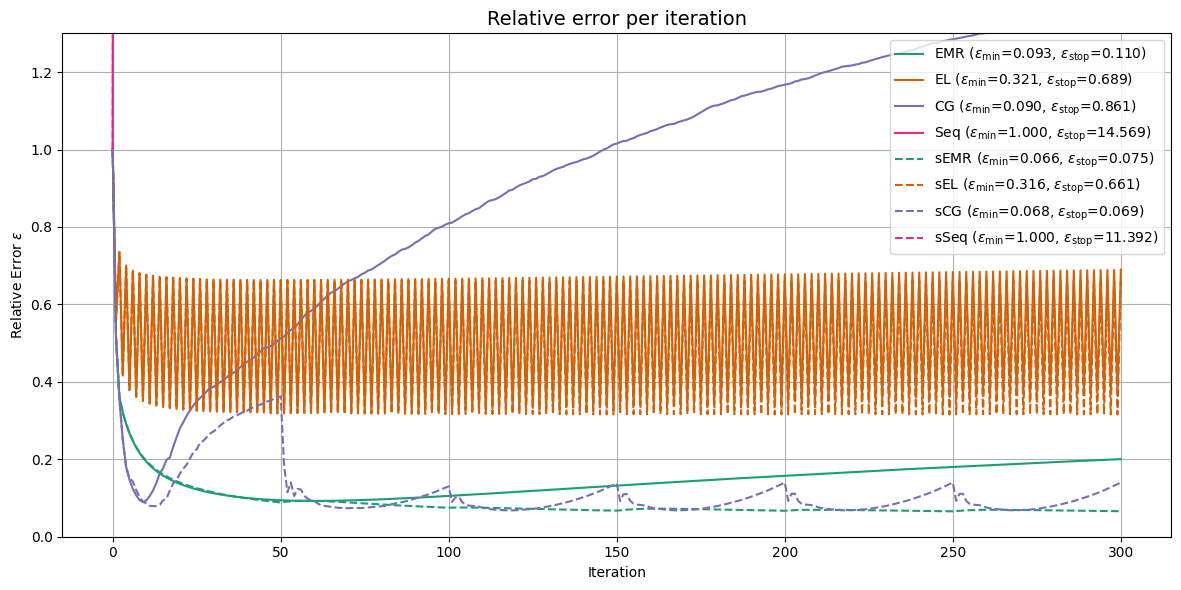

In [46]:
colors = ['#1b9e77','#d95f02','#7570b3','#e7298a','#66a61e']

fig, ax = plt.subplots(figsize=(12, 6))

min_al = rel_errors_feasibility_al.min()
min_el = rel_errors_feasibility_el.min()
min_cg = rel_errors_feasibility_cg.min()
min_seq = rel_errors_feasibility_seq.min()

stop_al = rel_errors_feasibility_al_early[-1]
stop_el = rel_errors_feasibility_el_early[-1]
stop_cg = rel_errors_feasibility_cg_early[-1]
stop_seq = rel_errors_feasibility_seq_early[-1]

min_sal = rel_errors_superiorization_al.min()
min_sel = rel_errors_superiorization_el.min()
min_scg = rel_errors_superiorization_cg.min()
min_sseq = rel_errors_superiorization_seq.min()

stop_sal = rel_errors_superiorization_al_early[-1]
stop_sel = rel_errors_superiorization_el_early[-1]
stop_scg = rel_errors_superiorization_cg_early[-1]
stop_sseq = rel_errors_superiorization_seq_early[-1]

ax.plot(rel_errors_feasibility_al, label=f'EMR ($\\epsilon_{{\\min}}$={min_al:.3f}, $\\epsilon_{{\\text{{stop}}}}$={stop_al:.3f})', color= colors[0])
ax.plot(rel_errors_feasibility_el, label=f'EL ($\\epsilon_{{\\min}}$={min_el:.3f}, $\\epsilon_{{\\text{{stop}}}}$={stop_el:.3f})', color= colors[1])
ax.plot(rel_errors_feasibility_cg, label=f'CG ($\\epsilon_{{\\min}}$={min_cg:.3f}, $\\epsilon_{{\\text{{stop}}}}$={stop_cg:.3f})', color= colors[2])
ax.plot(rel_errors_feasibility_seq, label=f'Seq ($\\epsilon_{{\\min}}$={min_seq:.3f}, $\\epsilon_{{\\text{{stop}}}}$={stop_seq:.3f})', color= colors[3])

ax.plot(rel_errors_superiorization_al, label=f'sEMR ($\\epsilon_{{\\min}}$={min_sal:.3f}, $\\epsilon_{{\\text{{stop}}}}$={stop_sal:.3f})', color= colors[0], linestyle='--')
ax.plot(rel_errors_superiorization_el, label=f'sEL ($\\epsilon_{{\\min}}$={min_sel:.3f}, $\\epsilon_{{\\text{{stop}}}}$={stop_sel:.3f})', color= colors[1], linestyle='--')
ax.plot(rel_errors_superiorization_cg, label=f'sCG ($\\epsilon_{{\\min}}$={min_scg:.3f}, $\\epsilon_{{\\text{{stop}}}}$={stop_scg:.3f})', color= colors[2], linestyle='--')
ax.plot(rel_errors_superiorization_seq, label=f'sSeq ($\\epsilon_{{\\min}}$={min_sseq:.3f}, $\\epsilon_{{\\text{{stop}}}}$={stop_sseq:.3f})', color= colors[3], linestyle='--')

ax.set_title('Relative error per iteration', fontsize=14)
ax.set_xlabel('Iteration')
ax.set_ylabel('Relative Error $\epsilon$')
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.savefig('CT_relative_errors_full_new_colorbar.png', dpi=300)

ax.set_ylim(0, 1.3)

ax.legend(loc = 'upper right')

plt.savefig('CT_relative_errors_new_colorbar.png', dpi=300)

plt.show()

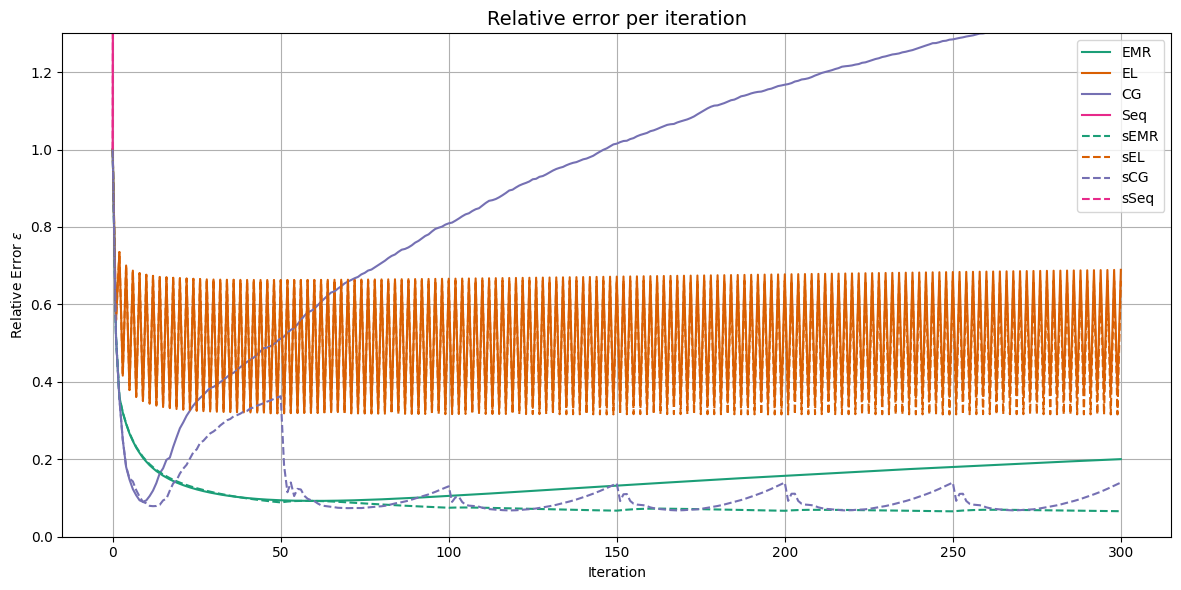

In [47]:
colors = ['#1b9e77','#d95f02','#7570b3','#e7298a','#66a61e']

fig, ax = plt.subplots(figsize=(12, 6))

min_al = rel_errors_feasibility_al.min()
min_el = rel_errors_feasibility_el.min()
min_cg = rel_errors_feasibility_cg.min()
min_seq = rel_errors_feasibility_seq.min()

stop_al = rel_errors_feasibility_al_early[-1]
stop_el = rel_errors_feasibility_el_early[-1]
stop_cg = rel_errors_feasibility_cg_early[-1]
stop_seq = rel_errors_feasibility_seq_early[-1]

min_sal = rel_errors_superiorization_al.min()
min_sel = rel_errors_superiorization_el.min()
min_scg = rel_errors_superiorization_cg.min()
min_sseq = rel_errors_superiorization_seq.min()

stop_sal = rel_errors_superiorization_al_early[-1]
stop_sel = rel_errors_superiorization_el_early[-1]
stop_scg = rel_errors_superiorization_cg_early[-1]
stop_sseq = rel_errors_superiorization_seq_early[-1]

ax.plot(rel_errors_feasibility_al, label='EMR', color=colors[0])
ax.plot(rel_errors_feasibility_el, label='EL', color=colors[1])
ax.plot(rel_errors_feasibility_cg, label='CG', color=colors[2])
ax.plot(rel_errors_feasibility_seq, label='Seq', color=colors[3])

ax.plot(rel_errors_superiorization_al, label='sEMR', color=colors[0], linestyle='--')
ax.plot(rel_errors_superiorization_el, label='sEL', color=colors[1], linestyle='--')
ax.plot(rel_errors_superiorization_cg, label='sCG', color=colors[2], linestyle='--')
ax.plot(rel_errors_superiorization_seq, label='sSeq', color=colors[3], linestyle='--')

ax.set_title('Relative error per iteration', fontsize=14)
ax.set_xlabel('Iteration')
ax.set_ylabel('Relative Error $\epsilon$')
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.savefig('CT_relative_errors_full_new_colorbar.png', dpi=300)

ax.set_ylim(0, 1.3)

ax.legend(loc = 'upper right')

plt.savefig('CT_relative_errors_clean_legend_new_colorbar.png', dpi=300)

plt.show()

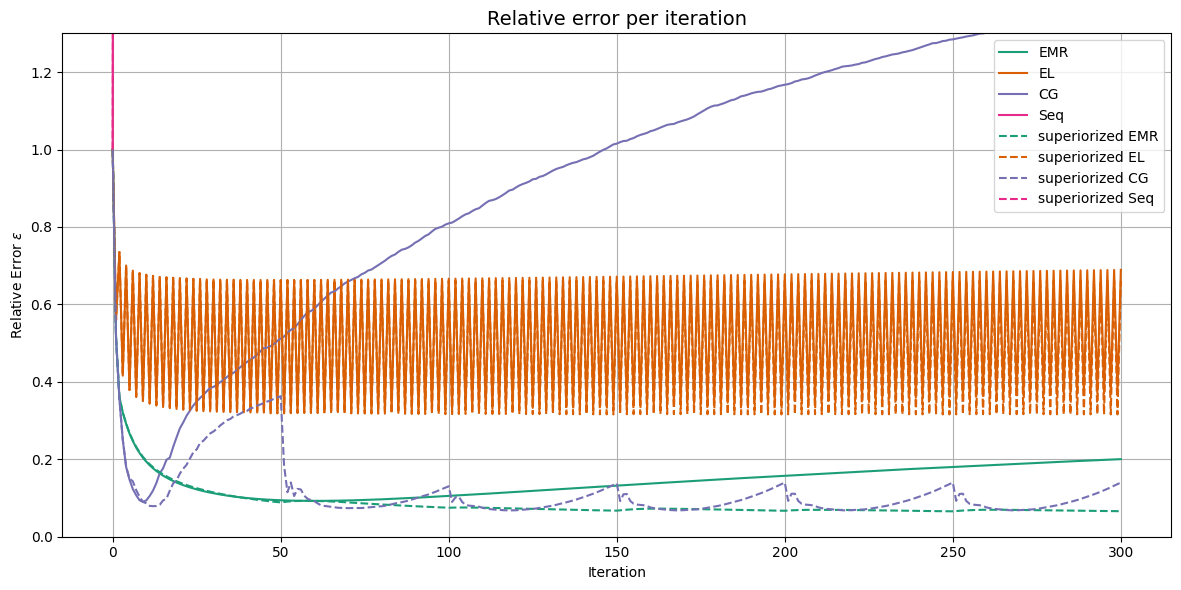

In [48]:
colors = ['#1b9e77','#d95f02','#7570b3','#e7298a','#66a61e']

fig, ax = plt.subplots(figsize=(12, 6))

min_al = rel_errors_feasibility_al.min()
min_el = rel_errors_feasibility_el.min()
min_cg = rel_errors_feasibility_cg.min()
min_seq = rel_errors_feasibility_seq.min()

stop_al = rel_errors_feasibility_al_early[-1]
stop_el = rel_errors_feasibility_el_early[-1]
stop_cg = rel_errors_feasibility_cg_early[-1]
stop_seq = rel_errors_feasibility_seq_early[-1]

min_sal = rel_errors_superiorization_al.min()
min_sel = rel_errors_superiorization_el.min()
min_scg = rel_errors_superiorization_cg.min()
min_sseq = rel_errors_superiorization_seq.min()

stop_sal = rel_errors_superiorization_al_early[-1]
stop_sel = rel_errors_superiorization_el_early[-1]
stop_scg = rel_errors_superiorization_cg_early[-1]
stop_sseq = rel_errors_superiorization_seq_early[-1]

ax.plot(rel_errors_feasibility_al, label='EMR', color=colors[0])
ax.plot(rel_errors_feasibility_el, label='EL', color=colors[1])
ax.plot(rel_errors_feasibility_cg, label='CG', color=colors[2])
ax.plot(rel_errors_feasibility_seq, label='Seq', color=colors[3])

ax.plot(rel_errors_superiorization_al, label='superiorized EMR', color=colors[0], linestyle='--')
ax.plot(rel_errors_superiorization_el, label='superiorized EL', color=colors[1], linestyle='--')
ax.plot(rel_errors_superiorization_cg, label='superiorized CG', color=colors[2], linestyle='--')
ax.plot(rel_errors_superiorization_seq, label='superiorized Seq', color=colors[3], linestyle='--')

ax.set_title('Relative error per iteration', fontsize=14)
ax.set_xlabel('Iteration')
ax.set_ylabel('Relative Error $\epsilon$')
ax.grid(True)
ax.legend()

plt.tight_layout()
# plt.savefig('CT_relative_errors_full.png', dpi=300)

ax.set_ylim(0, 1.3)

ax.legend(loc = 'upper right')

plt.savefig('CT_relative_errors_clean_legend_2_new_colorbar.png', dpi=300)

plt.show()

## Power series based

In [49]:
combs = [(0.99,5,4,20),
         (0.99,5,4,-1),
         (0.9,5,4,20),
         (0.9,5,4,-1),
         (0.9,1,1,-1)]

algs_superiorization_tv = {}
sols_superiorization_tv = {}
rel_errors_tv = {}

for comb in combs:
    step_size, step_size_modifier, n_red, n_restart = comb
    pert_tv = PowerSeriesGradientPerturbation(obj_cp.objective,obj_cp.gradient,step_size = step_size,n_restart= n_restart, n_red = n_red, step_size_modifier= step_size_modifier)
    alg_superiorization_tv = Superiorization(AdaptiveStepLandweberHyperplane(A_red_cp, cp.asarray(b_red_cp)),pert_tv)
    t_start = time.time()
    sol_tv = alg_superiorization_tv.solve(cp.zeros(A_red_cp.shape[1]),
                                                    max_iter = 300,proximity_measures = [("p_norm",2),"max_norm"],
                                                    storage = True)
    print("Superiorized TV Time (",comb,"): ", time.time() - t_start)
    algs_superiorization_tv[comb] = alg_superiorization_tv
    sols_superiorization_tv[comb] = sol_tv
    rel_errors_tv[comb] = np.array([np.linalg.norm(x_el - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_el in alg_superiorization_tv.all_x_basic])

Superiorized TV Time ( (0.99, 5, 4, 20) ):  20.436923265457153
Superiorized TV Time ( (0.99, 5, 4, -1) ):  14.513245105743408
Superiorized TV Time ( (0.9, 5, 4, 20) ):  14.196634531021118
Superiorized TV Time ( (0.9, 5, 4, -1) ):  13.106879472732544
Superiorized TV Time ( (0.9, 1, 1, -1) ):  12.94678020477295


### Early stopping

In [50]:
combs = [(0.99,5,4,20),
         (0.99,5,4,-1),
         (0.9,5,4,20),
         (0.9,5,4,-1),
         (0.9,1,1,-1)]

algs_superiorization_tv = {}
sols_superiorization_tv = {}
rel_errors_tv_early = {}

for comb in combs:
    stop_crit_sup = VarianceStoppingCriterion(0.01)
    step_size, step_size_modifier, n_red, n_restart = comb
    pert_tv = PowerSeriesGradientPerturbation(obj_cp.objective,obj_cp.gradient,step_size = step_size,n_restart= n_restart, n_red = n_red, step_size_modifier= step_size_modifier)
    alg_superiorization_tv = Superiorization(AdaptiveStepLandweberHyperplane(A_red_cp, cp.asarray(b_red_cp)),pert_tv)
    t_start = time.time()
    sol_tv = alg_superiorization_tv.solve(cp.zeros(A_red_cp.shape[1]),
                                                    max_iter = 300,proximity_measures = [("p_norm",2),"max_norm"],
                                                    storage = True,
                                                    alternative_stopping_criterion=stop_crit_sup.evaluate,
                                                    alternative_stopping_criterion_initial_call= stop_crit_sup.initial_call)

    print("Superiorized TV Time (",comb,"): ", time.time() - t_start, " with stopping criterion, iterations: ", len(alg_superiorization_tv.all_x_basic))
    algs_superiorization_tv[comb] = alg_superiorization_tv
    sols_superiorization_tv[comb] = sol_tv
    rel_errors_tv_early[comb] = np.array([np.linalg.norm(x_el - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_el in alg_superiorization_tv.all_x_basic])

Superiorized TV Time ( (0.99, 5, 4, 20) ):  7.450853109359741  with stopping criterion, iterations:  110
Superiorized TV Time ( (0.99, 5, 4, -1) ):  5.433693885803223  with stopping criterion, iterations:  110
Superiorized TV Time ( (0.9, 5, 4, 20) ):  5.153767347335815  with stopping criterion, iterations:  110
Superiorized TV Time ( (0.9, 5, 4, -1) ):  4.969521999359131  with stopping criterion, iterations:  110
Superiorized TV Time ( (0.9, 1, 1, -1) ):  4.6438703536987305  with stopping criterion, iterations:  110


## Adaptive Perturbation Step

In [51]:
from suppy.perturbations import AdaptiveStepGradientPerturbation


alg_feasibility_al_adaptive = AdaptiveStepLandweberHyperplane(A_red_cp, cp.asarray(b_red_cp))
TV_tilde = obj_cp.objective(alg_feasibility_al_adaptive.project((x0.copy())))
pert_adaptive = AdaptiveStepGradientPerturbation(obj_cp.objective,
                                                 obj_cp.gradient,
                                                 func_level = TV_tilde/2,
                                                 epsilon = TV_tilde/200,
                                                 noisy = False)

alg_superiorization_al_adaptive = Superiorization(alg_feasibility_al_adaptive,pert_adaptive)

t_start = time.time()
alg_superiorization_al_adaptive.solve(cp.zeros(A_red_cp.shape[1]),
                                                max_iter = 300,proximity_measures = [("p_norm",2),"max_norm"],
                                                storage = True)
print("Superiorized EMR with Adaptive Perturbation Time: ", time.time() - t_start)

rel_errors_superiorization_al_adaptive = np.array([np.linalg.norm(x_el - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_el in alg_superiorization_al_adaptive.all_x_basic])

Superiorized EMR with Adaptive Perturbation Time:  12.854366302490234


In [52]:
from suppy.perturbations import AdaptiveStepGradientPerturbation

stop_crit_sup = VarianceStoppingCriterion(0.01)

alg_feasibility_al_adaptive_early = AdaptiveStepLandweberHyperplane(A_red_cp, cp.asarray(b_red_cp))
TV_tilde = obj_cp.objective(alg_feasibility_al_adaptive_early.project((x0.copy())))
pert_adaptive_early = AdaptiveStepGradientPerturbation(obj_cp.objective,
                                                 obj_cp.gradient,
                                                 func_level = TV_tilde/2,
                                                 epsilon = TV_tilde/200,
                                                 noisy = False)

alg_superiorization_al_adaptive_early = Superiorization(alg_feasibility_al_adaptive_early,pert_adaptive_early)

t_start = time.time()
alg_superiorization_al_adaptive_early.solve(cp.zeros(A_red_cp.shape[1]),
                                                max_iter = 300,proximity_measures = [("p_norm",2),"max_norm"],
                                                storage = True,
                                                alternative_stopping_criterion=stop_crit_sup.evaluate,
                                                alternative_stopping_criterion_initial_call= stop_crit_sup.initial_call
                                                )
print("Superiorized EMR with Adaptive Perturbation Time: ", time.time() - t_start)

rel_errors_superiorization_al_adaptive_early = np.array([np.linalg.norm(x_el - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_el in alg_superiorization_al_adaptive_early.all_x_basic])

Superiorized EMR with Adaptive Perturbation Time:  4.494035243988037


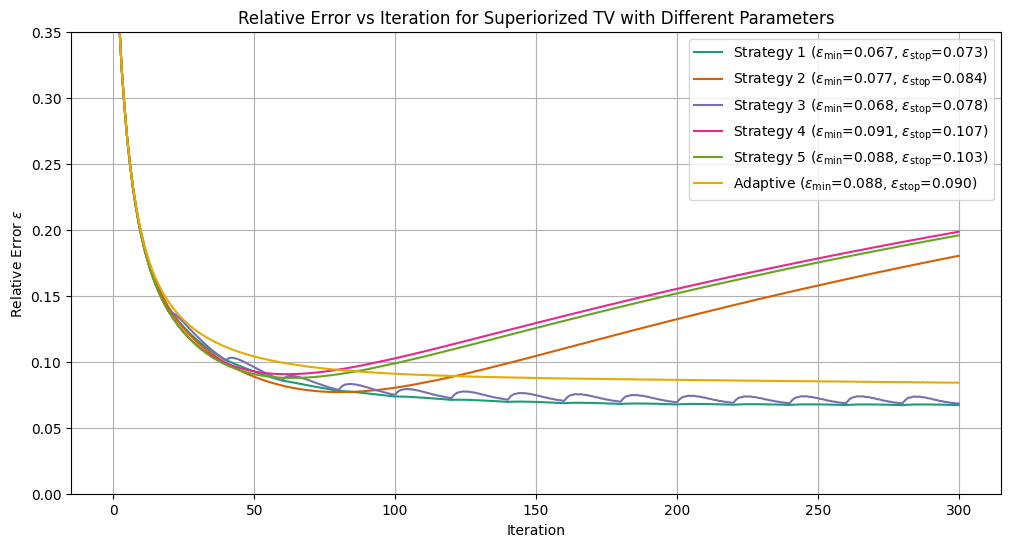

In [53]:
colors = ['#1b9e77','#d95f02','#7570b3','#e7298a','#66a61e','#e6ab02']

plt.figure(figsize = (12,6))
for (i,comb) in enumerate(combs):
    min_comb = rel_errors_tv[comb].min()
    stop_comb = rel_errors_tv_early[comb][-1]
    plt.plot(rel_errors_tv[comb], label=f'Strategy {i+1} ($\\epsilon_{{\\min}}$={min_comb:.3f}, $\\epsilon_{{\\text{{stop}}}}$={stop_comb:.3f})',color = colors[i])

stop_adaptive = rel_errors_superiorization_al_adaptive_early[-1]
plt.plot(rel_errors_superiorization_al_adaptive, label=f'Adaptive ($\\epsilon_{{\\min}}$={min_comb:.3f}, $\\epsilon_{{\\text{{stop}}}}$={stop_adaptive:.3f})',color = colors[i+1])

plt.xlabel('Iteration')
plt.ylabel('Relative Error $\epsilon$')
plt.title('Relative Error vs Iteration for Superiorized TV with Different Parameters')
plt.ylim(0,0.35)
plt.grid()
leg = plt.legend()
plt.savefig('CT_rel_error_TV_perturbations_new_colorbar.png', dpi=600, bbox_inches='tight')

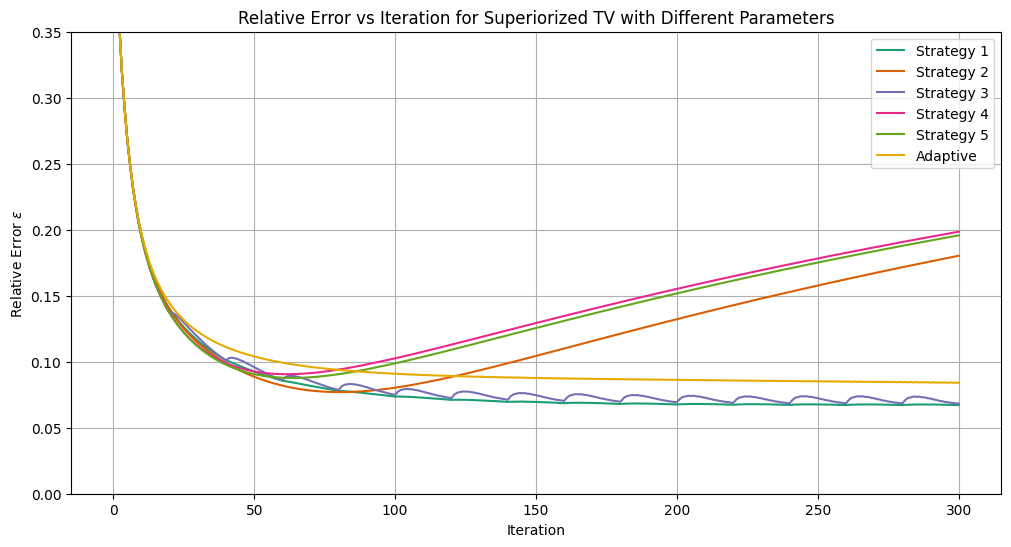

In [54]:
colors = ['#1b9e77','#d95f02','#7570b3','#e7298a','#66a61e','#e6ab02']

plt.figure(figsize = (12,6))
for (i,comb) in enumerate(combs):
    min_comb = rel_errors_tv[comb].min()
    stop_comb = rel_errors_tv_early[comb][-1]
    plt.plot(rel_errors_tv[comb], label=f'Strategy {i+1}',color = colors[i])

stop_adaptive = rel_errors_superiorization_al_adaptive_early[-1]
plt.plot(rel_errors_superiorization_al_adaptive, label='Adaptive',color = colors[i+1])

plt.xlabel('Iteration')
plt.ylabel('Relative Error $\epsilon$')
plt.title('Relative Error vs Iteration for Superiorized TV with Different Parameters')
plt.ylim(0,0.35)
plt.grid()
leg = plt.legend()
plt.savefig('CT_rel_error_TV_perturbations_clean_legend_new_colorbar.png', dpi=600, bbox_inches='tight')

In [55]:
115/6.57

17.50380517503805